In [47]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats




sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')
import plot_settings
import importlib
#import multi_exp_log
#import Param_symbol

import GP
import ecmm_node_cleaner_swell_GP_lib as _lib


from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)
    

COLORS = plot_settings.colors()

import_reload()
from ecmm_node_cleaner_swell_GP_lib import *
GP_FIT = GP.GP_process()

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/stress/../GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [48]:
RUN_ID = 'all1'

DT = 1
Q0 = 17921.57581 
SAVE  = False

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  3.0,
    's':  0.1
    }


LIMS = {
    'R0': (1e-3, 0.1),
    'R1': (5e-3, 0.1),
    'C1': (1e2, 2.5e4),
    'k':  (0.1, 10.0),
    's':  (0.01, 1.0)
    }

VARIABLES = ['R0', 'R1', 'C1']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'µm'
    }
N_VAR = len(VARIABLES)

In [49]:
# Alternaitvely load model as GLOBAL
model_name = 'ecm_node_0430_1313_staged_swelling_netR0_25.28min_32h_2000_100_S2b20eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)
# history, CONFIG, C1_final, N_HIDDEN, EPOCHS_STATIC, EPOCHS_DYNAMIC, EPOCHS_UNFREEZE = load_checkpoint(ckpt)
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')


Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 32, 'R1_constrained': 'true', 'R1_min': 0.005, 'R1_max': 0.2, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 50000.0, 'R0_constrained': 'true', 'R0_min': 0.008, 'R0_max': 0.015}
Using I_ref = 24.79
R1 constrained to [0.005, 0.2] Ohm
C1 unconstrained
R0 constrained to [0.008, 0.015] Ohm


## ECM solver module

In [50]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'../sr/sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format'][int(results_df['complexity'].idxmax()*.4)]# == int(results_df['complexity'].mean())]


        sym_expr = sp.sympify(expr)
        expressions[elem] = sym_expr

        
    
    return expressions['k'], expressions['R1'], expressions['C1']

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
k_expr, R1_expr, C1_expr = extract_expressions(RUN_ID)

display(Math('\\LARGE x_0 = \\mathrm{{C\\,rate}}\\quad x_1 = \\widetilde{d}\\quad x_2 = \\mathrm{{SOC}}'))
display(Math(f'\\LARGE f_{{C_1}}(x_0,x_1,x_2) = {sp.latex(C1_expr)}'))
display(Math(f'\\LARGE f_{{R_1}}(x_0,x_1,x_2)= {sp.latex(R1_expr)}'))
display(Math(f'\\LARGE f_k\\,(x_0,x_1,x_2) = {sp.latex(k_expr)}'))

k_func = sp.lambdify(('x0', 'x1', 'x2'), k_expr, 'numpy')
R1_func = sp.lambdify(('x0', 'x1', 'x2'), R1_expr, 'numpy')
C1_func = sp.lambdify(('x0', 'x1', 'x2'), C1_expr, 'numpy')


Loading symbolic regression results for RUN_ID: all1


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [51]:
def read_data(file_name, symbolic = True):
    if symbolic:
        df = pd.read_csv(
            f"symbol_data/{file_name}.txt",
            sep=',',
            comment="%"
        )
    else:
        df = pd.read_csv(
            f"{file_name}.txt",
            sep=';',
            comment="%"
        )
    return df

In [52]:
import scipy.signal as signal

def R0(i, d, SOC, NN = False, REF_VALUES = REF_VALUES, R0_func = R0_func, dummy = False):
    if dummy:
        return REF_VALUES['R0']
    if NN:
        return R0_nn(i, d, SOC)[0]
    else:
        return 0.01#R0_func(i, d, SOC) * REF_VALUES['R0']

def R1(i, d, SOC,R1_func = R1_func, Ref= REF_VALUES,NN = False, dummy = False):
    if dummy:
        return Ref['R1']
    if NN:
        return R1_nn(i, d, SOC)[0]
    else:
        return R1_func(i, d, SOC) * Ref['R1']

def C1(i, d, SOC,C1_func = C1_func, Ref= REF_VALUES, NN = False, dummy = False):
    if dummy:
        return Ref['C1']
    if NN:
        return C1_nn(i, d, SOC)[0]
    else:
        return (C1_func(i, d, SOC) * Ref['C1'])

def k(i, d, SOC, NN = False, Ref= REF_VALUES, k_func = k_func, dummy = False):
    if dummy:
        return np.ones_like(SOC) * Ref['k']/100
    if NN:
        return k_func(i, d, SOC) * REF_VALUES['k']/100 #k_nn(i, d, SOC)[0]
    else:
        return k_func(i, d, SOC) * REF_VALUES['k']/100 


def time_current_profile(C_rate,mode = 'DC'):
    I_0 = C_rate * Q0 / 3600
    if mode == 'DC':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = I_0 * np.ones_like(t)
        return I,t
    elif mode == 'pulse':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = signal.square(2 * np.pi * t / (3600 / C_rate)) * I_0 / 2 + I_0 / 2
        return I,t

def pulse_current_profile(t, C_rate, period = 400):
    I_0 = C_rate * Q0 / 3600
    I = I_0 * (signal.square(2 * np.pi * t / period) + 1)/2
    return I


In [61]:
def ECM_solve_du_fix(theta, i, t, RC2 = False, U0 = 0):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU1(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C 

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU1, U0, t, args=(theta[1],theta[2])).flatten()

    if RC2:
        U2 = scipy.integrate.odeint(dU1, U0, t, args=(theta[3],theta[4])).flatten()
    else: 
        U2 = 0
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model =  i*theta[0] + U

    return eta_model

def ECM_solve_curvefit(x, R0, R1, C1):
    t, i = x
    eta_model = ECM_solve_du_fix(theta=[R0, R1, C1], i=i, t=t)
    return eta_model


def parameter_estimation_curvefit(tr, p0=[0.01, 0.01, 1500],lims = LIMS, U0 = 0):
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]], [lims['R0'][1], lims['R1'][1], lims['C1'][1]])

    xdata = [tr['t'], tr['I']]
    ydata = -tr['V'] + tr['Ue']
    popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit, xdata, ydata, p0=p0, bounds=bounds)
    R0, R1 , C1 = popt
    #print(f"Estimated parameters: R0={R0:.4f} Ohm, R1={R1:.4f} Ohm, C1={C1:.2f} F")
    eta = ECM_solve_curvefit(xdata, R0, R1, C1)
    return -eta + tr['Ue'], tr['t']


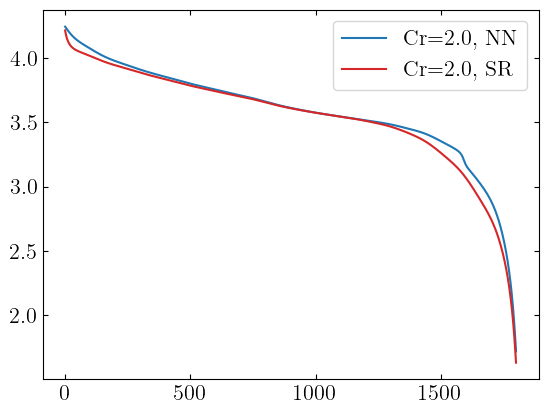

In [54]:
def ECM_solve_du(u_par,C_rate, RC2 = False, U0 = 0, discharge = True, mode = 'DC', NN = False, tmax = None, dummy = False):
    
    if tmax is not None:
        t = np.arange(0, tmax, DT)
    else:
        t = np.arange(0, 2 * int(3600 / C_rate), DT)
    if discharge:
        pass
        #print(f"Simulating discharge at C-rate: {C_rate}x and u_par: {u_par}")
    else:
        C_rate = -C_rate
        #print(f"Simulating charge at C-rate: {C_rate}x and u_par: {u_par}")

    if mode == 'pulse':
        def I_interp(t):
            return pulse_current_profile(t, C_rate)
    else:
        i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity
        I_interp = interp1d(t, i, fill_value="extrapolate")

    i = I_interp(t)
    if not discharge:
        #i = -i
        soc0 = 0
    else:        
        soc0 = 1

    #print(f"Initial conditions: SOC={soc0}, U1={U0}")
    def dSOC(SOC, t, C_rate=C_rate, u_par=u_par):
        I_t = I_interp(t)
        return -I_t / Q0
    
    
    def SOC(t,SOC0=soc0):
        SOC_t = scipy.integrate.odeint(dSOC, SOC0, t).flatten()
        return SOC_t
    
    SOC_t = SOC(t)
    #plt.show()
    soc_interp = interp1d(t,SOC_t,bounds_error=False,fill_value=(SOC_t[0], SOC_t[-1]))

    def dU(V_1, t, soc_int = soc_interp, d = u_par, NN = NN):
        I_t = I_interp(t)
        SOC_t = soc_int(t)
        if not discharge:
            SOC_t = 1 - SOC_t
        R = R1(np.abs(C_rate), d, SOC_t, NN = NN, dummy = dummy)
        C = C1(np.abs(C_rate), d, SOC_t, NN = NN, dummy = dummy)
        return -V_1 / (R * C) + I_t / C 
    
    def mech(t, soc_int = soc_interp, d = u_par, NN = NN):
        SOC_t = soc_int(t)
        return k(np.abs(C_rate), d, SOC_t, NN = NN,dummy=dummy)*d

    # Solve ODE
    

    def ECM_system(y, t, u_par, NN = NN):

        SOC, U1 = y
        #if t == 0:
            #print(f"Initial conditions: SOC={SOC}, U1={U1}")

        I_t = I_interp(t)

        if not discharge:

            SOC_eff = 1 - SOC

        else:

            SOC_eff = SOC
        R = R1(np.abs(C_rate), u_par, SOC_eff, NN = NN,dummy=dummy)
        C = C1(np.abs(C_rate), u_par, SOC_eff, NN = NN, dummy = dummy)
        dSOC_dt = -I_t / Q0

        dU1_dt = -U1 / (R * C) + I_t / C

        return [dSOC_dt, dU1_dt]

    U1 = scipy.integrate.odeint(dU, U0, t).flatten()
    y0 = [soc0, U0]

    sol = scipy.integrate.odeint(ECM_system, y0, t, args=(u_par,))

    SOC_t = sol[:, 0]

    U1 = sol[:, 1]

    U = U1 #+ U2
    # Voltage model
    R0_vals = []
    for s in SOC_t:
        R0_vals.append(R0(np.abs(C_rate),u_par,s, NN = NN, dummy = dummy))
    eta_model =  i*R0_vals + U
    V_B = GP.soc_to_Ue(SOC_t, GP_FIT) - eta_model

    if not discharge:
        valid_inds = V_B< 5.5
    else:
        valid_inds = (SOC_t < 1.0) & (SOC_t > 0.0)
    V_B = V_B[valid_inds]
    t = t[valid_inds]
    soc = SOC_t[valid_inds]
    Ue = GP.soc_to_Ue(soc, GP_FIT)
    i = I_interp(t)

    return V_B,soc, Ue,i ,t, mech(t)


for C_rate in np.arange(2, 2.5, 0.5):
    V_B,soc,Ue,i,t,F = ECM_solve_du(1,C_rate, discharge=True, mode = 'DC', NN = True, dummy= False)
    plt.plot(t, V_B, label=f'Cr={C_rate}, NN', color = COLORS[0])
    V_B,soc,Ue,i,t,F = ECM_solve_du(1,C_rate, discharge=True, mode = 'DC', NN = False)
    plt.plot(t, V_B, label=f'Cr={C_rate}, SR', color = COLORS[1])
#plt.plot(np.linspace(0,1,100), GP.soc_to_Ue(np.linspace(0,1,100), GP_FIT), color = 'k',ls = '--', label='True $U_e$')
plt.legend()
plt.show()

# for u in np.arange(1, 29, 5):
#     V_B,soc,Ue,i,t,F = ECM_solve_du(u,2)
#     plt.scatter(u, F.min(), label=f'u={u}')
#     plt.scatter(u, F.max(), label=f'u={u}')


In [55]:
# V_B,soc,Ue,i,t,F = ECM_solve_du(3.7,3, discharge = True, mode = 'DC', NN = True)
# f, ax = plt.subplots()
# #ax2 = ax.twinx()
# #ax2.plot(t, i, label='Mechanical Force', color = 'tab:red', alpha = 0.5)
# #ax.plot(t, V_B, label='Battery Voltage') 
# ax.plot(soc, V_B, label='Battery Voltage') 
# ax.plot(soc,Ue, 'black', ls = '--',label='Equilibrium Potential')
# ax.set_xlabel('Time [s]')
# ax.set_ylabel('Voltage [V]')
# ax.legend()

In [56]:
# V_B,soc,Ue,i,t,F = ECM_solve_du(1,2, discharge = False, mode = 'pulse')
# f, ax = plt.subplots()

# #ax2.plot(t, i, label='Mechanical Force', color = 'tab:red', alpha = 0.5)
# ax.plot(t, V_B, label='Battery Voltage') 
# ax.plot(t, Ue, label='Battery Voltage') 
# #plt.plot(t, soc, label=f'C={C_rate}x')

In [141]:
df_true = read_data('merged_DC_hyper', symbolic=False)
display(df_true.head())
split_train = int(df_true['trajectory'].max() * 0.8)

df_test = df_true[df_true['trajectory'] >= split_train]
df_train = df_true[df_true['trajectory'] < split_train]

print(f'F_max in test set: {df_true["F"][df_true['t'] == 0].max():.2f} ') 

,u_par,C,t,V,I,F,u,Ue,soc,trajectory,eta
0,21.5,4.36,0,4.172390,21.70502,0.091712,-3.090249,4.324993,0.999998,0,0.152603
1,21.5,4.36,1,4.121311,21.70502,0.091735,-3.090249,4.321312,0.998789,0,0.200001
2,21.5,4.36,2,4.103575,21.70502,0.091752,-3.090249,4.317624,0.997578,0,0.214049
3,21.5,4.36,3,4.089090,21.70502,0.091769,-3.090249,4.313936,0.996367,0,0.224846
4,21.5,4.36,4,4.076761,21.70502,0.091786,-3.090249,4.310248,0.995156,0,0.233488


F_max in test set: 0.15 


Selected trajectory index: 95
Selected trajectory parameters: C=4.84, u_par=15.9
Estimated parameters: R0=0.0091 Ohm, R1=0.0095 Ohm, C1=25000.00 F


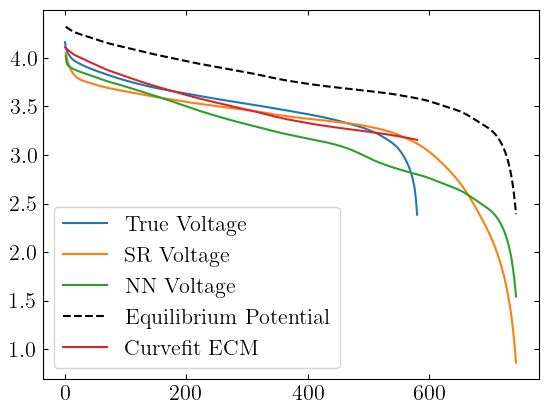

In [58]:
u_C_pairs = df_test.loc[df_true['t'] == 0, ['u_par', 'C', 'trajectory']]



C = 5

traj = int(np.argmin(np.abs(u_C_pairs['C'] - C))) + split_train

print(f"Selected trajectory index: {traj}")
C_ext = u_C_pairs.loc[u_C_pairs['trajectory'] == traj, 'C'].values[0]
u_par_ext = u_C_pairs.loc[u_C_pairs['trajectory'] == traj, 'u_par'].values[0]

print(f"Selected trajectory parameters: C={C_ext}, u_par={u_par_ext}")

plt.plot(df_true.loc[df_true['trajectory'] == traj, 't'], df_true.loc[df_true['trajectory'] == traj, 'V'], label='True Voltage')


V_B,soc,Ue,i,t,F = ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC')
plt.plot(t, V_B, label='SR Voltage')
V_B,soc,Ue,i,t,F = ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = True)
plt.plot(t, V_B, label='NN Voltage')
plt.plot(t, Ue, label='Equilibrium Potential', color = 'k', ls = '--')

VB_fix, t = parameter_estimation_curvefit(df_true.loc[df_true['trajectory'] == traj])
plt.plot(t, VB_fix, label='Curvefit ECM')
#plt.plot(t[:len(df_true.loc[df_true['trajectory'] == traj, 't'])], V_B[:len(df_true.loc[df_true['trajectory'] == traj, 't'])], label='NN Voltage')
plt.legend()
# compare lengths 


In [129]:
def scale(df = df_true, variables = ['V','F']):
    scaled_df = df.copy()
    range_val = {}
    for var in variables:
        min_val = df[var].min()
        max_val = df[var].max()
        range_val[var] = (max_val - min_val)
    return range_val


def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    #mae = np.mean(np.abs(y_true - y_pred))
    #r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    return rmse

def simulate_and_evaluate(df):
    scaling = scale()
    N = df['trajectory'].nunique()
    rmse_SR = np.zeros((N,2))
    rmse_NN = np.zeros((N,2))
    rmse_fix = np.zeros(N)
    obs_inpt = np.zeros((N,2))
    V_true_all = []
    F_true_all = []
    V_pred_SR_all = []
    F_pred_SR_all = []
    V_pred_NN_all = [] 
    F_pred_NN_all = []
    V_pred_fix_all = []
    for i in trange(N):
        traj = i + split_train
        V_true = df.loc[df['trajectory'] == traj, 'V'].values
        F_true = df.loc[df['trajectory'] == traj, 'F'].values

        #print(f"Evaluating trajectory {traj} with {len(V_true)} data points.")

        C = df.loc[df['trajectory'] == traj, 'C'].values[0]
        u_par = df.loc[df['trajectory'] == traj, 'u_par'].values[0]

        obs_inpt[i,0] = C
        obs_inpt[i,1] = u_par

        V_B_NN,_,_,_,_,F_NN = ECM_solve_du(u_par,C, discharge = True, mode = 'DC', NN = True, tmax=len(V_true) +1, dummy = False)
        V_B, _,_,_,_,F = ECM_solve_du(u_par,C, discharge = True, mode = 'DC', NN = False, tmax=len(V_true) +1 , dummy = False)
        V_B_fix,_ = parameter_estimation_curvefit(df.loc[df['trajectory'] == traj])
        #n = min(len(V_true), len(V_B), len(V_B_NN))
        
        #V_true = V_true[:n]

        #F_true = F_true[:n]

        #V_B = V_B[:n]

        #F = F[:n]

        #V_B_NN = V_B_NN[:n]

        #F_NN = F_NN[:n]

        #print(f'lengths: V_true={len(V_true)}, F_true={len(F_true)}, V_B={len(V_B)}, F={len(F)}, V_B_NN={len(V_B_NN)}, F_NN={len(F_NN)}')
        #Y_true = np.concatenate((V_true, F_true))
        #Y_pred_NN = np.concatenate((V_B_NN, F_NN))
        #Y_pred = np.concatenate((V_B, F))  
        rmse_fix[i] = metrics(V_true, V_B_fix) / scaling['V']
        rmse_SR[i,0] = metrics(V_true, V_B) / scaling['V']
        rmse_SR[i,1] = metrics(F_true, F) / scaling['F']
        rmse_NN[i,0] = metrics(V_true, V_B_NN) / scaling['V']
        rmse_NN[i,1] = metrics(F_true, F_NN) / scaling['F']
        V_true_all.append(V_true)
        F_true_all.append(F_true)
        V_pred_SR_all.append(V_B)
        F_pred_SR_all.append(F)
        V_pred_NN_all.append(V_B_NN)
        F_pred_NN_all.append(F_NN)
        V_pred_fix_all.append(V_B_fix)
    return rmse_SR, rmse_NN, rmse_fix, obs_inpt, V_true_all, F_true_all, V_pred_SR_all, F_pred_SR_all, V_pred_NN_all, F_pred_NN_all, V_pred_fix_all

In [130]:
rmse_SR, rmse_NN, rmse_fix,obs_inpt,V_true, F_true, V_pred_SR, F_pred_SR,V_pred_NN,F_pred_NN,V_pred_fix = simulate_and_evaluate(df_test)

  0%|          | 0/21 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:36<00:00,  1.75s/it]


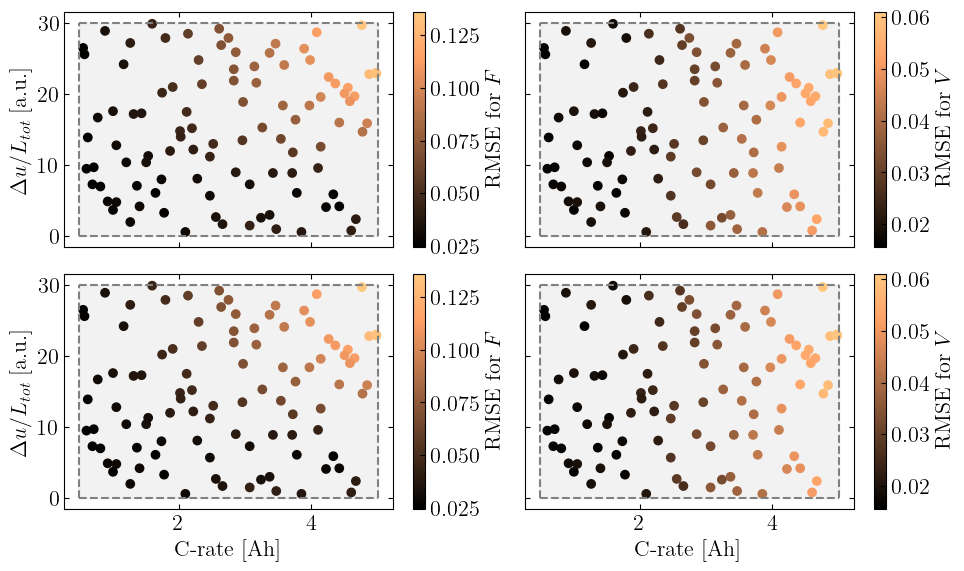

In [63]:
f, ax = plt.subplots(2, 2, figsize=(10, 6), sharex='col', sharey='col')

for a in ax.flat:
    a.vlines(0.5,0,30, color='gray', linestyle='--')
    a.vlines(5,0,30, color='gray', linestyle='--')
    a.hlines(0,0.5,5, color='gray', linestyle='--')
    a.hlines(30,0.5,5, color='gray', linestyle='--')
    a.fill_between([0.5, 5], 0, 30, color='gray', alpha=0.1)

ax[0,0].set_ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
ax[1,0].set_ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
ax[1,0].set_xlabel('C-rate [Ah]')
ax[1,1].set_xlabel('C-rate [Ah]')
for a in ax[0, :]:
    a.tick_params(labelbottom=False)  # hide top row x labels

for a in ax[:, 1]:
    a.tick_params(labelleft=False)    # hide right column y labels

# Scatter plots with different colormaps
sc0 = ax[0,0].scatter(
    obs_inpt[:,0],
     obs_inpt[:,1],
    c=rmse_NN[:,0] ,
    cmap='copper',   # changed color
    label='Test'
)

sc1 = ax[0,1].scatter(
    obs_inpt[:,0],
     obs_inpt[:,1],
    c=rmse_SR[:,0],
    cmap='copper',  # changed color
    label='Train'
)

sc2 = ax[1,0].scatter(
    obs_inpt[:,0],
     obs_inpt[:,1],
    c=rmse_NN[:,0],
    cmap='copper',   # changed color
    label='Test'
)

sc3 = ax[1,1].scatter(
    obs_inpt[:,0],
     obs_inpt[:,1],
    c=rmse_SR[:,0],
    cmap='copper',  # changed color
    label='Train'
)

# Attach each colorbar to its own axis
cb0 = plt.colorbar(sc0, ax=ax[0,0], label = 'RMSE for $F$')
cb1 = plt.colorbar(sc1, ax=ax[0,1], label = 'RMSE for $V$')
cb2 = plt.colorbar(sc2, ax=ax[1,0], label = 'RMSE for $F$')
cb3 = plt.colorbar(sc3, ax=ax[1,1], label = 'RMSE for $V$')

plt.tight_layout()



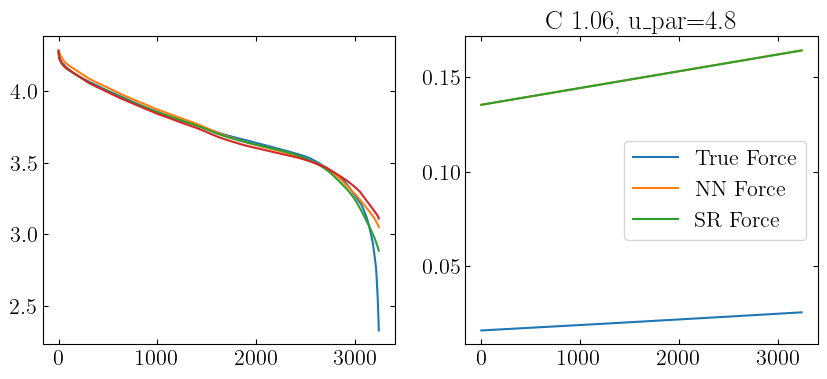

In [133]:
ind = 15
t = df_true.loc[df_true['trajectory'] == ind + split_train, 't'].values
f,ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(t,V_true[ind], label='True volt')
ax[0].plot(t,V_pred_NN[ind], label='NN volt')
ax[0].plot(t,V_pred_SR[ind], label='SR volt')
ax[0].plot(t,V_pred_fix[ind], label='Curvefit ECM volt')
ax[1].plot(F_true[ind], label='True Force')
ax[1].plot(F_pred_NN[ind], label='NN Force')
ax[1].plot(F_pred_SR[ind], label='SR Force')
#plt.plot(df_test.loc[df_test['trajectory'] == ind + split_train, 'V'].values)
#plt.plot()
#V_B,soc,Ue,i,t,F = ECM_solve_du(obs_inpt[ind,1],obs_inpt[ind,0], discharge = True, mode = 'DC', NN = False, tmax=len(df_test.loc[df_test['trajectory'] == ind + split_train, 'V'].values)+1, dummy = False)
#plt.plot(t, V_B, label='ECM volt')
plt.title(f'C {obs_inpt[ind,0]}, u_par={obs_inpt[ind,1]}')
plt.legend()

In [135]:
avg_Nrmse_NN_V = np.mean(rmse_NN[:,0])
avg_Nrmse_NN_F = np.mean(rmse_NN[:,1])
avg_Nrmse_SR_V = np.mean(rmse_SR[:,0])
avg_Nrmse_SR_F = np.mean(rmse_SR[:,1])
avg_Nrmse_fix_V = np.mean(rmse_fix)
rmse_fix_V = np.vstack((rmse_fix, np.zeros_like(rmse_fix))).T   



print(rmse_fix_V.shape, rmse_NN.shape, rmse_SR.shape)

(21, 2) (21, 2) (21, 2)


In [136]:
print(f"Average NRMSE for NN Voltage: {avg_Nrmse_NN_V:.4f}")
print(f"Average NRMSE for NN Force: {avg_Nrmse_NN_F:.4f}")
print(f"Average NRMSE for SR Voltage: {avg_Nrmse_SR_V:.4f}")
print(f"Average NRMSE for SR Force: {avg_Nrmse_SR_F:.4f}")
print(f"Average NRMSE for Curvefit ECM Voltage: {avg_Nrmse_fix_V:.4f}")

Average NRMSE for NN Voltage: 0.0513
Average NRMSE for NN Force: 2.2482
Average NRMSE for SR Voltage: 0.0304
Average NRMSE for SR Force: 2.2482
Average NRMSE for Curvefit ECM Voltage: 0.0418


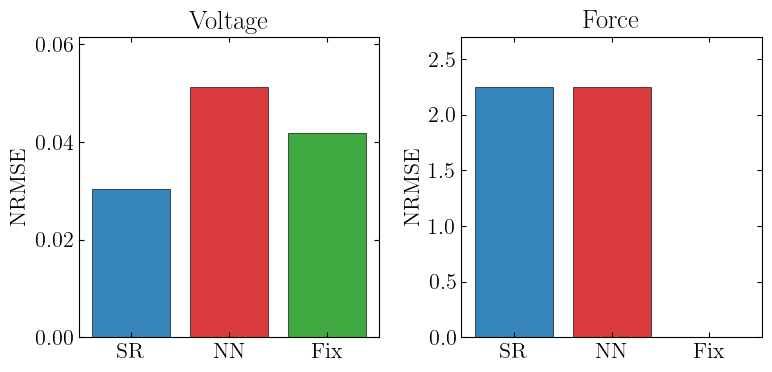

In [146]:
metric_names = ['Voltage', 'Force']
methods = ['SR', 'NN', 'Fix']

bar_plot_dict = {
    'NN Voltage': avg_Nrmse_NN_V,
    'NN Force': avg_Nrmse_NN_F,
    'SR Voltage': avg_Nrmse_SR_V,
    'SR Force': avg_Nrmse_SR_F,
    'Fix Voltage': avg_Nrmse_fix_V,
    'Fix Force': np.zeros_like(avg_Nrmse_fix_V)
}

n_methods = len(methods)
n_metrics = len(metric_names)

fig, ax = plt.subplots(
    1,
    n_metrics,
    figsize=(4 * n_metrics, 4),
    sharey=False
)

# Handle single subplot case
if n_metrics == 1:
    ax = [ax]

for j, metric in enumerate(metric_names):

    # Collect values dynamically from dictionary
    vals = []

    for method in methods:
        key = f'{method} {metric}'
        vals.append(np.mean(bar_plot_dict[key]))

    bars = ax[j].bar(
        methods,
        vals,
        color=[COLORS[i % len(COLORS)] for i in range(n_methods)], alpha = 0.9, edgecolor='black', linewidth=.5
    )

    ax[j].set_title(metric)
    ax[j].set_ylabel('NRMSE')
    ax[j].set_ylim(0, max(vals) * 1.2)
    # add error bars for min and max in the rmse values across trajectories

    # ax[j].errorbar(
    #     methods,
    #     vals,
    #     yerr=[np.min(vals), np.max(vals)],
    #     fmt='none',
    #     ecolor='black',
    #     capsize=5
    # )
    # 
    # for b in bars:
    #     h = b.get_height()
    #     ax[j].text(
    #         b.get_x() + b.get_width() / 2,
    #         h,
    #         f'{h:.3f}',
    #         ha='center',
    #         va='bottom',
    #         fontsize=9
    #     )

plt.tight_layout()
plt.show()